# Wicket Forecast Engine — Phases 1 & 2

**Phase 1:** Data Pipeline Integrity — chronological split, calibration-only lookups, XP residuals.  
**Phase 2:** Log-Odds Skill Interaction Model — bounded wicket probability via logit/sigmoid, multiplicative run factor.

---
**Progress:**
- [x] **Phase 1** — Data Pipeline Integrity & Leakage Elimination
- [x] **Phase 2** — Log-Odds Skill Interaction Model
- [ ] Phase 3 — Monte Carlo Simulation Engine
- [ ] Phase 4 — Backtesting & Calibration
- [ ] Phase 5 — Tactical Decision Optimizer
- [ ] Phase 6 — Visualization & Communication

## 0. Configuration

All constants live in `src/forecast/config.py`. Override them there — **never** hardcode values in notebook cells.

In [1]:
import sys
from pathlib import Path

# Ensure the project root is on the Python path so src.forecast resolves
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
import pandas as pd
import numpy as np

# -- Config (single source of truth) --
from src.forecast.config import (
    CALIBRATION_CUTOFF_DATE,
    MIN_SAMPLE_SIZE,
    MIN_BALLS_BATTER,
    MIN_BALLS_BOWLER,
    BALL_BY_BALL_PATH,
)

print(f"Project root  : {PROJECT_ROOT}")
print(f"Data file     : {BALL_BY_BALL_PATH}")
print(f"Cutoff date   : {CALIBRATION_CUTOFF_DATE}")
print(f"Min sample    : {MIN_SAMPLE_SIZE} deliveries per lookup cell")
print(f"Min balls (B) : {MIN_BALLS_BATTER} | Min balls (BW): {MIN_BALLS_BOWLER}")

Project root  : C:\ARKO\Projects\GitHub\Beyond Instinct
Data file     : C:\ARKO\Projects\GitHub\Beyond Instinct\data\consolidated_t20_data.csv
Cutoff date   : 2024-01-01
Min sample    : 30 deliveries per lookup cell
Min balls (B) : 120 | Min balls (BW): 120


## 1. Load Raw Data

In [2]:
from src.forecast.data_pipeline import load_ball_by_ball

df_raw = load_ball_by_ball()

print(f"Loaded {len(df_raw):,} deliveries across {df_raw['match_id'].nunique():,} matches")
print(f"Date range: {df_raw['start_date'].min().date()} → {df_raw['start_date'].max().date()}")
print(f"Columns: {df_raw.columns.tolist()}")

Loaded 720,644 deliveries across 3,193 matches
Date range: 2005-02-17 → 2026-03-04
Columns: ['match_id', 'season', 'start_date', 'venue', 'city', 'gender', 'match_type', 'team_type', 'innings', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'runs_off_bat', 'extras', 'total_runs', 'is_wicket', 'player_out', 'wicket_type', 'wides', 'noballs', 'byes', 'legbyes', 'penalty']


## 2. Chronological Split (No Randomisation)

> **Why not `train_test_split`?**  
> A random split allows future data to "teach" the model about past events.
> In a T20 context, IPL 2024 knowledge must never inform an IPL 2023 projection.
> The split function below asserts zero match-ID overlap before returning.

In [3]:
from src.forecast.data_pipeline import split_calibration_evaluation

df_calib_raw, df_eval_raw = split_calibration_evaluation(df_raw)

[Split] Calibration: 2005-02-17 -> 2023-12-31 (1968 matches, 447,194 deliveries)
[Split] Evaluation:  2024-01-12 -> 2026-03-04 (1225 matches, 273,450 deliveries)


## 3. Match-State Feature Engineering

Enriches each delivery with **pre-ball** context: cumulative runs, wickets, balls remaining, rate bins. All values are lagged by one delivery — no same-ball information leaks into the state used for prediction.

In [4]:
from src.forecast.data_pipeline import add_match_state_features

print("Engineering state features for calibration set...")
df_calib_state = add_match_state_features(df_calib_raw)

print("Engineering state features for evaluation set...")
df_eval_state = add_match_state_features(df_eval_raw)

# Inspect
state_cols = [
    'match_id', 'innings', 'over', 'ball',
    'cumulative_runs', 'cumulative_wickets', 'cumulative_legal_balls',
    'balls_remaining', 'wickets_in_hand', 'active_rate', 'rate_bin'
]
print("\nSample calibration rows (state features):")
display(df_calib_state[state_cols].head(10))

Engineering state features for calibration set...
Engineering state features for evaluation set...

Sample calibration rows (state features):


,match_id,innings,over,ball,cumulative_runs,cumulative_wickets,cumulative_legal_balls,balls_remaining,wickets_in_hand,active_rate,rate_bin
0,211028,1,0,1,0,0,0,120,10,0.000000,very_low
1,211028,1,0,2,0,0,1,119,10,0.000000,very_low
2,211028,1,0,3,1,0,2,118,10,0.500000,very_low
3,211028,1,0,4,1,0,3,117,10,0.333333,very_low
4,211028,1,0,5,1,0,4,116,10,0.250000,very_low
5,211028,1,0,6,1,0,5,115,10,0.200000,very_low
6,211028,1,0,7,2,0,5,115,10,0.400000,very_low
7,211028,1,1,1,4,0,6,114,10,0.666667,very_low
8,211028,1,1,2,4,0,7,113,10,0.571429,very_low
9,211028,1,1,3,4,0,8,112,10,0.500000,very_low


## 4. Build Empirical Lookups (Calibration Set Only)

The 4-level fallback hierarchy (level0 → level3) is built **exclusively** from
`df_calib_state`. The evaluation set is never passed to this function.

In [5]:
from src.forecast.data_pipeline import build_empirical_lookups

# IMPORTANT: only the calibration set goes in here
lookups = build_empirical_lookups(df_calib_state)

print("\nLevel-0 sample (most granular lookup):")
display(lookups['level0'].head(10))

print("\nLevel-3 (innings-level grand mean — the ultimate fallback):")
display(lookups['level3'])

[Lookups] level0: 8750 cells built (min sample >= 30 gate applied at query time)
[Lookups] level1: 1574 cells built (min sample >= 30 gate applied at query time)
[Lookups] level2: 354 cells built (min sample >= 30 gate applied at query time)
[Lookups] level3: 4 cells built (min sample >= 30 gate applied at query time)

Level-0 sample (most granular lookup):


,innings,rate_bin,balls_remaining,wickets_in_hand,xR_batter,xR_bowler,xW,sample_size
0,1,high,0,5,0.000000,0.000000,1.000000,1
1,1,high,1,1,1.307692,1.307692,0.307692,13
2,1,high,1,2,1.833333,1.895833,0.229167,48
3,1,high,1,3,2.098592,2.140845,0.154930,71
4,1,high,1,4,1.754717,1.839623,0.179245,106
5,1,high,1,5,1.870370,1.925926,0.157407,108
6,1,high,1,6,1.782051,1.910256,0.141026,78
7,1,high,1,7,2.358974,2.358974,0.153846,39
8,1,high,1,8,1.950000,2.000000,0.150000,20
9,1,high,1,9,0.333333,0.333333,0.333333,3



Level-3 (innings-level grand mean — the ultimate fallback):


,innings,xR_batter,xR_bowler,xW,sample_size
0,1,1.151523,1.199556,0.056396,238439
1,2,1.117720,1.166122,0.055431,208528
2,3,1.861789,1.943089,0.105691,123
3,4,1.836538,1.951923,0.096154,104


## 5. Compute Per-Delivery XP Metrics (Calibration Set Only)

In [6]:
from src.forecast.data_pipeline import compute_xp_metrics

# XP is computed on calibration only — evaluating player skill on the
# same data used for projection would be self-fulfilling.
df_calib_xp = compute_xp_metrics(df_calib_state, lookups)

print("\nSample XP columns:")
xp_cols = ['batter', 'bowler', 'runs_off_bat', 'is_wicket',
           'xR_batter_baseline', 'xR_bowler_baseline', 'xW_baseline',
           'BattingXP', 'BowlingXP', 'WicketXP_raw']
display(df_calib_xp[xp_cols].head(10))

[XP] Computing baselines for each delivery — this may take a moment...

Sample XP columns:


,batter,bowler,runs_off_bat,is_wicket,xR_batter_baseline,xR_bowler_baseline,xW_baseline,BattingXP,BowlingXP,WicketXP_raw
0,ME Trescothick,B Lee,0,0,0.666821,0.773716,0.025451,-0.666821,-0.773716,-0.025451
1,ME Trescothick,B Lee,1,0,0.875351,0.943768,0.030928,0.124649,0.056232,-0.030928
2,GO Jones,B Lee,0,0,0.802218,0.864140,0.042514,-0.802218,-0.864140,-0.042514
3,GO Jones,B Lee,0,0,0.853484,0.902664,0.044057,-0.853484,-0.902664,-0.044057
4,GO Jones,B Lee,0,0,0.884935,0.956109,0.043891,-0.884935,-0.956109,-0.043891
5,GO Jones,B Lee,0,0,0.780366,0.846922,0.043261,-0.780366,0.153078,-0.043261
6,GO Jones,B Lee,2,0,0.780366,0.846922,0.043261,1.219634,1.153078,-0.043261
7,ME Trescothick,GD McGrath,0,0,0.754209,0.860269,0.040404,-0.754209,-0.860269,-0.040404
8,ME Trescothick,GD McGrath,0,0,0.986135,1.072790,0.034662,-0.986135,-1.072790,-0.034662
9,ME Trescothick,GD McGrath,0,0,0.840367,0.915596,0.053211,0.000000,0.084404,-0.053211


## 6. Aggregate Player XP

In [7]:
from src.forecast.data_pipeline import aggregate_player_xp

batter_xp, bowler_xp = aggregate_player_xp(
    df_calib_xp,
    min_balls_batter=MIN_BALLS_BATTER,
    min_balls_bowler=MIN_BALLS_BOWLER,
)

print("\n--- BattingXP Leaderboard (Top 15, sorted by XP/ball) ---")
display(
    batter_xp.sort_values('BattingXP_per_ball', ascending=False)
    [['batter', 'balls_faced', 'total_runs_scored', 'BattingXP_per_ball', 'WicketXP_raw_per_ball']]
    .head(15)
    .reset_index(drop=True)
)

print("\n--- BowlingXP Leaderboard (Top 15, most negative = best bowler) ---")
display(
    bowler_xp.sort_values('BowlingXP_per_ball', ascending=True)
    [['bowler', 'balls_bowled', 'total_runs_conceded', 'BowlingXP_per_ball', 'WicketXP_raw_per_ball']]
    .head(15)
    .reset_index(drop=True)
)

[XP Agg] Qualified batters: 870, Qualified bowlers: 928

--- BattingXP Leaderboard (Top 15, sorted by XP/ball) ---


,batter,balls_faced,total_runs_scored,BattingXP_per_ball,WicketXP_raw_per_ball
0,PV Vuniwaqa,141,245,0.685207,-0.022702
1,OJ Hairs,203,392,0.658713,0.021993
2,KJ Stagno,290,508,0.617393,0.009890
3,Kuldeep,225,377,0.556781,0.003291
4,Iqbal Hossain,227,381,0.529140,0.014971
5,Faisal Khan,230,380,0.521672,0.009593
6,G Stewart,219,360,0.512941,0.009715
7,HS Gericke,237,387,0.493149,0.018585
8,SA Yadav,1242,2135,0.478866,-0.017105
9,Taranjeet Singh,456,776,0.464623,-0.003973



--- BowlingXP Leaderboard (Top 15, most negative = best bowler) ---


,bowler,balls_bowled,total_runs_conceded,BowlingXP_per_ball,WicketXP_raw_per_ball
0,P Kumbhare,205,145,-0.448445,0.001313
1,K Hinds,168,143,-0.409733,0.001264
2,AY Patel,156,118,-0.407998,0.014827
3,TM Odoyo,126,106,-0.390856,0.020400
4,A Natubhai Ahir,135,118,-0.381196,-0.010643
5,BJ Currie,120,96,-0.370066,0.046554
6,I Danladi,195,148,-0.364205,0.023660
7,RA Abolarin,150,127,-0.359653,0.001872
8,G Stewart,204,185,-0.359355,-0.021221
9,Hamid Mahmood,120,97,-0.340957,-0.005001


## 7. Phase 1 Validation Checks

All checks must pass before proceeding to Phase 2.

In [8]:
from src.forecast.data_pipeline import validate_no_eval_leakage

# ----- Check 1: Zero match-ID overlap between splits -----
calib_ids = set(df_calib_raw['match_id'].unique())
eval_ids = set(df_eval_raw['match_id'].unique())
overlap = calib_ids & eval_ids
assert len(overlap) == 0, f"FAIL: {len(overlap)} match IDs appear in both splits!"
print(f"✅ Check 1 PASSED: Zero match-ID overlap ({len(calib_ids)} calib / {len(eval_ids)} eval)")

# ----- Check 2: Lookup tables contain no match_id column -----
validate_no_eval_leakage(lookups, df_eval_raw)
print("✅ Check 2 PASSED: No match_id columns in any lookup table")

# ----- Check 3: XP baselines are finite (no NaN/inf from bad division) -----
for col in ['xR_batter_baseline', 'xR_bowler_baseline', 'xW_baseline']:
    n_bad = (~df_calib_xp[col].apply(np.isfinite)).sum()
    assert n_bad == 0, f"FAIL: {n_bad} non-finite values in {col}"
print("✅ Check 3 PASSED: All baseline columns are finite")

# ----- Check 4: xW in [0,1] — it's a probability -----
xw_min = df_calib_xp['xW_baseline'].min()
xw_max = df_calib_xp['xW_baseline'].max()
assert 0.0 <= xw_min, f"FAIL: xW_baseline has negative values (min={xw_min})"
assert xw_max <= 1.0, f"FAIL: xW_baseline exceeds 1.0 (max={xw_max})"
print(f"✅ Check 4 PASSED: xW_baseline ∈ [{xw_min:.4f}, {xw_max:.4f}]")

# ----- Check 5: Player XP eligibility gates are honoured -----
assert (batter_xp['balls_faced'] >= MIN_BALLS_BATTER).all(), "FAIL: Under-threshold batter in XP table"
assert (bowler_xp['balls_bowled'] >= MIN_BALLS_BOWLER).all(), "FAIL: Under-threshold bowler in XP table"
print(f"✅ Check 5 PASSED: All {len(batter_xp)} batters ≥{MIN_BALLS_BATTER} balls, "
      f"all {len(bowler_xp)} bowlers ≥{MIN_BALLS_BOWLER} balls")

print("\n" + "="*60)
print("  PHASE 1 COMPLETE — All validation checks passed ✅")
print("  Proceed to Phase 2: Log-Odds Skill Interaction Model")
print("="*60)

✅ Check 1 PASSED: Zero match-ID overlap (1968 calib / 1225 eval)
[Validation] No match_id columns in any lookup table. Evaluation set (1225 matches) structurally isolated.
✅ Check 2 PASSED: No match_id columns in any lookup table
✅ Check 3 PASSED: All baseline columns are finite
✅ Check 4 PASSED: xW_baseline ∈ [0.0000, 0.3636]
✅ Check 5 PASSED: All 870 batters ≥120 balls, all 928 bowlers ≥120 balls

  PHASE 1 COMPLETE — All validation checks passed ✅
  Proceed to Phase 2: Log-Odds Skill Interaction Model


## 8. Export Artefacts for Phase 2

Persist the calibration-enriched DataFrames and player XP tables so Phase 2
doesn't need to re-run the full pipeline from scratch.

In [9]:
import pickle
from pathlib import Path

ARTEFACT_DIR = PROJECT_ROOT / 'models' / 'phase1_artefacts'
ARTEFACT_DIR.mkdir(parents=True, exist_ok=True)

# Save lookups dict (small enough for pickle)
with open(ARTEFACT_DIR / 'lookups.pkl', 'wb') as f:
    pickle.dump(lookups, f)

# Save player XP tables
batter_xp.to_parquet(ARTEFACT_DIR / 'batter_xp.parquet', index=False)
bowler_xp.to_parquet(ARTEFACT_DIR / 'bowler_xp.parquet', index=False)

# Save evaluation set (state-enriched) for Phase 3/4
df_eval_state.to_parquet(ARTEFACT_DIR / 'df_eval_state.parquet', index=False)

print(f"Phase 1 artefacts saved to: {ARTEFACT_DIR}")
print(f"  lookups.pkl       — 4-level empirical lookup tables")
print(f"  batter_xp.parquet — {len(batter_xp)} qualified batters")
print(f"  bowler_xp.parquet — {len(bowler_xp)} qualified bowlers")
print(f"  df_eval_state.parquet — {df_eval_state['match_id'].nunique()} evaluation matches")

Phase 1 artefacts saved to: C:\ARKO\Projects\GitHub\Beyond Instinct\models\phase1_artefacts
  lookups.pkl       — 4-level empirical lookup tables
  batter_xp.parquet — 870 qualified batters
  bowler_xp.parquet — 928 qualified bowlers
  df_eval_state.parquet — 1225 evaluation matches


---
# Phase 2 — Log-Odds Skill Interaction Model

## The Mathematical Problem We're Fixing

The original engine computed:
```python
adj_xw = max(0, min(1, base_xw + bat_wxp_pb + bowl_wxp_pb))  # WRONG
adj_xr = max(0, base_xr + bat_xp_pb + bowl_xp_pb)            # WRONG
```

**Two critical flaws:**
1. **Linear additivity**: Probabilities don't add linearly. `clip(0,1)` is a hack, not a model.
2. **No contextual sensitivity**: A +0.03 adjustment at base_xw=0.03 is a 100% increase; at base_xw=0.50 it's only 6%. The same delta should behave differently at different baseline levels.

## The Fix
```
adj_xw = sigmoid(logit(base_xw) + bowl_wkt_logodds + bat_wkt_logodds)   # bounded in (0,1) by construction
adj_xr = base_xr * exp(bat_run_logfactor + bowl_run_logfactor)           # always positive by construction
```
Player skill is now expressed in **log-odds space** (for wickets) and **log-ratio space** (for runs).
Both are naturally additive and require no manual clipping.

In [10]:
# Phase 2 — Step 1: Load Phase 1 artefacts
import sys
from pathlib import Path
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pickle
import pandas as pd
import numpy as np

ARTEFACT_DIR = PROJECT_ROOT / 'models' / 'phase1_artefacts'

with open(ARTEFACT_DIR / 'lookups.pkl', 'rb') as f:
    lookups = pickle.load(f)

df_calib_xp = pd.read_parquet(ARTEFACT_DIR / 'df_calib_xp.parquet')

print(f'Loaded XP dataset: {len(df_calib_xp):,} deliveries')
print(f'xW_baseline range: [{df_calib_xp["xW_baseline"].min():.4f}, {df_calib_xp["xW_baseline"].max():.4f}]')
print(f'Columns: {df_calib_xp.columns.tolist()}')

Loaded XP dataset: 100,000 deliveries
xW_baseline range: [0.0000, 0.2703]
Columns: ['match_id', 'season', 'start_date', 'venue', 'city', 'gender', 'match_type', 'team_type', 'innings', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'runs_off_bat', 'extras', 'total_runs', 'is_wicket', 'player_out', 'wicket_type', 'wides', 'noballs', 'byes', 'legbyes', 'penalty', 'cumulative_runs', 'cumulative_wickets', 'is_legal_ball', 'cumulative_legal_balls', 'balls_remaining', 'wickets_in_hand', 'target', 'scoring_rate', 'asking_rate', 'active_rate', 'rate_bin', 'bowler_runs_conceded', 'xR_batter_baseline', 'xR_bowler_baseline', 'xW_baseline', 'BattingXP', 'BowlingXP', 'WicketXP_raw']


In [11]:
# Phase 2 — Step 2: Build player skill profiles in log-odds / log-ratio space
from src.forecast.skill_model import build_player_skill_profiles
from src.forecast.config import MIN_BALLS_BATTER, MIN_BALLS_BOWLER

batter_skill, bowler_skill = build_player_skill_profiles(
    df_calib_xp,
    min_balls_batter=MIN_BALLS_BATTER,
    min_balls_bowler=MIN_BALLS_BOWLER,
)

print(f'Batter skill profiles shape: {batter_skill.shape}')
print(f'Bowler skill profiles shape: {bowler_skill.shape}')

[SkillModel] Qualified batters: 218, Qualified bowlers: 259
Batter skill profiles shape: (218, 8)
Bowler skill profiles shape: (259, 8)


In [12]:
# Phase 2 — Step 3: Inspect skill leaderboards
#
# bat_wkt_logodds: NEGATIVE = good batter (survives more than expected)
#                  POSITIVE = poor batter (gets out more than expected)
# bat_run_logfactor: POSITIVE = good batter (scores more than expected)
#
# bowl_wkt_logodds: POSITIVE = good bowler (takes more wickets than expected)
#                   NEGATIVE = poor bowler
# bowl_run_logfactor: NEGATIVE = good bowler (concedes less than expected)

print('--- Top 15 Batters by Survival (most negative bat_wkt_logodds) ---')
display(
    batter_skill.sort_values('bat_wkt_logodds', ascending=True)
    [['batter', 'balls_faced', 'bat_actual_wkt_rate', 'bat_context_wkt_rate',
      'bat_wkt_logodds', 'bat_run_logfactor']]
    .round(4).head(15).reset_index(drop=True)
)

print('--- Top 15 Bowlers by Wicket-Taking (most positive bowl_wkt_logodds) ---')
display(
    bowler_skill.sort_values('bowl_wkt_logodds', ascending=False)
    [['bowler', 'balls_bowled', 'bowl_actual_wkt_rate', 'bowl_context_wkt_rate',
      'bowl_wkt_logodds', 'bowl_run_logfactor']]
    .round(4).head(15).reset_index(drop=True)
)

--- Top 15 Batters by Survival (most negative bat_wkt_logodds) ---


,batter,balls_faced,bat_actual_wkt_rate,bat_context_wkt_rate,bat_wkt_logodds,bat_run_logfactor
0,Yasir Ali,180,0.0167,0.0470,-1.0682,-0.0102
1,F Behardien,154,0.0260,0.0685,-1.0139,0.0835
2,MC Henriques,135,0.0222,0.0507,-0.8536,0.0988
3,Mohammad Rizwan,541,0.0222,0.0504,-0.8506,0.0935
4,DP Conway,311,0.0257,0.0562,-0.8133,0.1717
5,RN ten Doeschate,233,0.0258,0.0535,-0.7595,0.1016
6,Ehsan Khan,138,0.0507,0.0944,-0.6682,0.0536
7,MK Pandey,539,0.0278,0.0526,-0.6616,0.0241
8,JP Duminy,194,0.0309,0.0575,-0.6482,0.0724
9,HM Amla,186,0.0269,0.0495,-0.6335,0.0938


--- Top 15 Bowlers by Wicket-Taking (most positive bowl_wkt_logodds) ---


,bowler,balls_bowled,bowl_actual_wkt_rate,bowl_context_wkt_rate,bowl_wkt_logodds,bowl_run_logfactor
0,Iqbal Hussain,137,0.1460,0.0708,0.8087,-0.1015
1,LC Le Tissier,138,0.0797,0.0398,0.7360,-0.2566
2,Aminul Islam,138,0.0797,0.0431,0.6538,0.0811
3,Kuldeep Yadav,453,0.0883,0.0487,0.6377,-0.0065
4,Usman Qadir,192,0.0781,0.0443,0.6028,0.0617
5,MNM Aslam,120,0.0917,0.0529,0.5908,-0.1268
6,TK Patel,132,0.0833,0.0485,0.5794,0.0345
7,A Krishna,139,0.0863,0.0506,0.5724,0.2101
8,S Vijayakumar,168,0.0714,0.0432,0.5319,0.0524
9,Umar Adam,156,0.0833,0.0515,0.5149,-0.1456


In [13]:
# Phase 2 — Step 4: Matchup Adjustment Explorer
# Shows how the log-odds model changes probabilities vs. the old linear model
from src.forecast.skill_model import compute_matchup_adjustments

# Define a test matchup and a baseline context
BASE_XW = 0.055   # ~5.5% wicket probability in this over/state context
BASE_XR = 1.15    # ~1.15 runs per ball in this context

# Try a selection of interesting matchups
test_pairs = [
    ('SA Yadav',    'JJ Bumrah'),
    ('SA Yadav',    'TA Boult'),
    ('V Kohli',     'JJ Bumrah'),
    ('V Kohli',     'TA Boult'),
    ('UNKNOWN_BAT', 'JJ Bumrah'),   # unknown batter = neutral adjustment
    ('SA Yadav',    'UNKNOWN_BWL'), # unknown bowler = neutral adjustment
]

rows = []
for batter, bowler in test_pairs:
    result = compute_matchup_adjustments(
        base_xr=BASE_XR, base_xw=BASE_XW,
        batter_name=batter, bowler_name=bowler,
        batter_skill=batter_skill, bowler_skill=bowler_skill,
    )
    # Old linear model (for comparison — the WRONG approach)
    bat_raw_xp = batter_skill[batter_skill['batter'] == batter]['bat_wkt_logodds'].values
    bowl_raw_xp = bowler_skill[bowler_skill['bowler'] == bowler]['bowl_wkt_logodds'].values
    rows.append({
        'Batter': batter,
        'Bowler': bowler,
        'base_xW': round(BASE_XW, 4),
        'adj_xW (Phase2)': round(result['adj_xw'], 4),
        'base_xR': round(BASE_XR, 4),
        'adj_xR (Phase2)': round(result['adj_xr'], 4),
        'bowl_logodds': round(result['bowl_wkt_logodds'], 3),
        'bat_logodds': round(result['bat_wkt_logodds'], 3),
    })

matchup_df = pd.DataFrame(rows)
print(f'Matchup Adjustment Table (base_xW={BASE_XW}, base_xR={BASE_XR})')
display(matchup_df)

Matchup Adjustment Table (base_xW=0.055, base_xR=1.15)


,Batter,Bowler,base_xW,adj_xW (Phase2),base_xR,adj_xR (Phase2),bowl_logodds,bat_logodds
0,SA Yadav,JJ Bumrah,0.055,0.0527,1.15,0.9791,-0.045,0.000
1,SA Yadav,TA Boult,0.055,0.0529,1.15,1.2707,-0.041,0.000
2,V Kohli,JJ Bumrah,0.055,0.0317,1.15,1.0872,-0.045,-0.529
3,V Kohli,TA Boult,0.055,0.0319,1.15,1.4111,-0.041,-0.529
4,UNKNOWN_BAT,JJ Bumrah,0.055,0.0527,1.15,0.9791,-0.045,0.000
5,SA Yadav,UNKNOWN_BWL,0.055,0.0550,1.15,1.1500,0.000,0.000


In [14]:
# Phase 2 — Step 5: Validation Assertions
from src.forecast.skill_model import adjusted_wicket_prob, adjusted_run_expectation

# --- Check 1: All adj_xw values from all real matchup combos in (0,1) ---
# Compute adj_xw for every batter x bowler combination in the data
# Use the grand-mean baseline as reference
grand_xw = df_calib_xp['xW_baseline'].mean()
grand_xr = df_calib_xp['xR_batter_baseline'].mean()

all_adj_xw = []
for _, brow in batter_skill.iterrows():
    for _, bowrow in bowler_skill.iterrows():
        p = adjusted_wicket_prob(grand_xw, bowrow['bowl_wkt_logodds'], brow['bat_wkt_logodds'])
        all_adj_xw.append(p)

all_adj_xw_arr = np.array(all_adj_xw)
assert (all_adj_xw_arr > 0).all() and (all_adj_xw_arr < 1).all(), \
    f'FAIL: adj_xw out of (0,1): min={all_adj_xw_arr.min():.6f}, max={all_adj_xw_arr.max():.6f}'
print(f'Check 1 PASSED: adj_xw in (0,1) for all {len(all_adj_xw):,} batter-bowler combos')
print(f'  Range: [{all_adj_xw_arr.min():.5f}, {all_adj_xw_arr.max():.5f}]')
print(f'  Mean:  {all_adj_xw_arr.mean():.5f}  (base: {grand_xw:.5f})')

# --- Check 2: All adj_xr values strictly positive ---
all_adj_xr = []
for _, brow in batter_skill.iterrows():
    for _, bowrow in bowler_skill.iterrows():
        r = adjusted_run_expectation(grand_xr, brow['bat_run_logfactor'], bowrow['bowl_run_logfactor'])
        all_adj_xr.append(r)

all_adj_xr_arr = np.array(all_adj_xr)
assert (all_adj_xr_arr > 0).all(), f'FAIL: adj_xr has non-positive values: min={all_adj_xr_arr.min()}'
print(f'Check 2 PASSED: adj_xr > 0 for all {len(all_adj_xr):,} batter-bowler combos')
print(f'  Range: [{all_adj_xr_arr.min():.4f}, {all_adj_xr_arr.max():.4f}]')

# --- Check 3: bat_wkt_logodds and bowl_wkt_logodds have opposite sign conventions ---
# A 'good' batter (survives more) has NEGATIVE bat_wkt_logodds
# A 'good' bowler (takes more wickets) has POSITIVE bowl_wkt_logodds
# Verify: best batter's bat_wkt_logodds is the MINIMUM (most negative)
best_batter_survival = batter_skill.sort_values('bat_actual_wkt_rate').iloc[0]
best_batter_logodds_is_negative = best_batter_survival['bat_wkt_logodds'] < batter_skill['bat_wkt_logodds'].median()
assert best_batter_logodds_is_negative, 'FAIL: best survival batter should have below-median bat_wkt_logodds'
print(f'Check 3 PASSED: Best survival batter ({best_batter_survival["batter"]}) has '
      f'bat_wkt_logodds={best_batter_survival["bat_wkt_logodds"]:.3f} (below median)')

print('\n' + '='*60)
print('  PHASE 2 COMPLETE -- All validation checks passed [PASS]')
print('  Proceed to Phase 3: Monte Carlo Simulation Engine')
print('='*60)

Check 1 PASSED: adj_xw in (0,1) for all 56,462 batter-bowler combos
  Range: [0.00509, 0.20417]
  Mean:  0.05539  (base: 0.05422)
Check 2 PASSED: adj_xr > 0 for all 56,462 batter-bowler combos
  Range: [0.5144, 2.6803]
Check 3 PASSED: Best survival batter (Yasir Ali) has bat_wkt_logodds=-1.068 (below median)

  PHASE 2 COMPLETE -- All validation checks passed [PASS]
  Proceed to Phase 3: Monte Carlo Simulation Engine


In [15]:
# Phase 2 — Step 6: Export skill profiles for Phase 3
P2_ARTEFACT_DIR = PROJECT_ROOT / 'models' / 'phase2_artefacts'
P2_ARTEFACT_DIR.mkdir(parents=True, exist_ok=True)

batter_skill.to_parquet(P2_ARTEFACT_DIR / 'batter_skill.parquet', index=False)
bowler_skill.to_parquet(P2_ARTEFACT_DIR / 'bowler_skill.parquet', index=False)

print(f'Phase 2 artefacts saved to: {P2_ARTEFACT_DIR}')
print(f'  batter_skill.parquet -- {len(batter_skill)} qualified batters')
print(f'  bowler_skill.parquet -- {len(bowler_skill)} qualified bowlers')
print()
print('Phase 1 + Phase 2 ready. Inputs for Phase 3 Monte Carlo:')
print('  lookups      : 4-level baseline lookup (calibration-only)')
print('  batter_skill : log-odds wicket delta + run log-factor per batter')
print('  bowler_skill : log-odds wicket delta + run log-factor per bowler')

Phase 2 artefacts saved to: C:\ARKO\Projects\GitHub\Beyond Instinct\models\phase2_artefacts
  batter_skill.parquet -- 218 qualified batters
  bowler_skill.parquet -- 259 qualified bowlers

Phase 1 + Phase 2 ready. Inputs for Phase 3 Monte Carlo:
  lookups      : 4-level baseline lookup (calibration-only)
  batter_skill : log-odds wicket delta + run log-factor per batter
  bowler_skill : log-odds wicket delta + run log-factor per bowler


---
# Phase 3 -- Monte Carlo Ball-by-Ball Simulation Engine

## What We're Replacing

The original `predict_innings_trajectory()` computed a **single deterministic path**:
```python
for over in remaining:
    exp_runs += base_xr + bat_xp + bowl_xp  # one number, no uncertainty
```
This gives a point estimate with no confidence interval, no scenario distribution,
and no accounting for tail-collapse risk.

## The Fix: 10,000 Stochastic Paths

```
For each of 10,000 simulations, in parallel:
  For each remaining ball:
    1. Look up baseline xW, xR from 3D numpy table (innings x over x wickets_in_hand)
    2. Apply Phase 2 log-odds adjustment: adj_xw = sigmoid(logit(xW) + bowl_logodds + bat_logodds)
    3. Apply Phase 2 run factor:          adj_xr = xR * exp(bat_runfac + bowl_runfac)
    4. Draw wicket outcome: Bernoulli(adj_xw)
    5. If no wicket: sample run from empirical distribution mixed by adj_xr scale
    6. If wicket: advance batting lineup state machine
```

Output: full score distribution -> P10, P50, P90 confidence band, P(win), P(collapse).

In [16]:
# Phase 3 -- Step 1: Load artefacts and initialise simulator
import sys
from pathlib import Path
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from src.forecast.simulator import (
    InningsSimulator, build_scoring_distribution, SimulationResult
)

# Load Phase 1 & 2 artefacts
P1_DIR = PROJECT_ROOT / 'models' / 'phase1_artefacts'
P2_DIR = PROJECT_ROOT / 'models' / 'phase2_artefacts'

with open(P1_DIR / 'lookups.pkl', 'rb') as f:
    lookups = pickle.load(f)

batter_skill = pd.read_parquet(P2_DIR / 'batter_skill.parquet')
bowler_skill  = pd.read_parquet(P2_DIR / 'bowler_skill.parquet')
df_calib_xp   = pd.read_parquet(P1_DIR / 'df_calib_xp.parquet')

# Build empirical scoring distribution from calibration data
scoring_dist = build_scoring_distribution(df_calib_xp)
print(f'Scoring distribution built: {len(scoring_dist)} context entries')

# Initialise the simulator (pre-builds all lookup tables at init time)
sim = InningsSimulator(lookups, batter_skill, bowler_skill, scoring_dist)

Scoring distribution built: 40 context entries
[Simulator] Ready. 218 batters, 259 bowlers in skill registry.


In [17]:
# Phase 3 -- Step 2: Define match scenario
# Edit these variables to simulate any match state

# -- Current match state --
INNINGS       = 1         # 1 = batting first, 2 = chasing
CURRENT_OVER  = 15        # Over number (0-indexed; overs 0-19)
CURRENT_RUNS  = 120       # Runs on the board so far
CURRENT_WKTS  = 3         # Wickets fallen
TARGET        = None      # Set to an integer for innings 2 chase scenarios

# -- Remaining batting lineup (in order) --
# First entry = current on-strike batter
BATTING_LINEUP = [
    'SA Yadav',    # current batter (check batter_skill for available names)
    'HH Pandya',
    'AD Russell',
    'KA Pollard',
    'SP Narine',
    'JJ Roy',
    'Tailender 1',
    'Tailender 2',
    'Tailender 3',
    'Tailender 4',
]

# -- Bowling plan: {over_number: bowler_name} --
# Overs not in the plan use a neutral (unknown) bowler adjustment
BOWLING_PLAN = {
    15: 'JJ Bumrah',
    16: 'TA Boult',
    17: 'JJ Bumrah',
    18: 'TA Boult',
    19: 'JJ Bumrah',
}

# Simulation parameters
N_SIMULATIONS = 10_000
SEED          = 42

print(f'Scenario: Innings {INNINGS}, Over {CURRENT_OVER}/20, {CURRENT_RUNS}/{CURRENT_WKTS}')
print(f'Remaining balls: {(20 - CURRENT_OVER) * 6}')
if TARGET:
    print(f'Chase target: {TARGET} (need {TARGET - CURRENT_RUNS} more runs)')

Scenario: Innings 1, Over 15/20, 120/3
Remaining balls: 30


In [18]:
# Phase 3 -- Step 3: Run simulation
import time
t0 = time.time()

result = sim.simulate(
    innings       = INNINGS,
    current_over  = CURRENT_OVER,
    current_runs  = CURRENT_RUNS,
    current_wickets = CURRENT_WKTS,
    batting_lineup  = BATTING_LINEUP,
    bowling_plan    = BOWLING_PLAN,
    target          = TARGET,
    n_simulations   = N_SIMULATIONS,
    seed            = SEED,
)
elapsed = time.time() - t0

print(f'Simulation completed in {elapsed:.2f}s ({N_SIMULATIONS:,} paths)')
print()
print('--- Result Summary ---')
for k, v in result.summary().items():
    print(f'  {k:20s}: {v}')
print()
print('--- Over-by-Over Trajectory ---')
display(result.over_snapshot_df())

Simulation completed in 0.24s (10,000 paths)

--- Result Summary ---
  score_p10           : 151
  score_median        : 163
  score_p90           : 176
  score_mean          : 163.4
  wickets_median      : 5.0
  p_collapse          : 0.446

--- Over-by-Over Trajectory ---


,over_completed,runs_p10,runs_median,runs_p90,wickets_median,paths_alive_pct
0,15,123.0,127.0,133.0,3.0,100.00
1,16,130.0,136.0,144.0,4.0,100.00
2,17,136.0,145.0,154.0,4.0,99.99
3,18,144.0,154.0,165.0,5.0,99.87
4,19,151.0,163.0,176.0,5.0,98.33


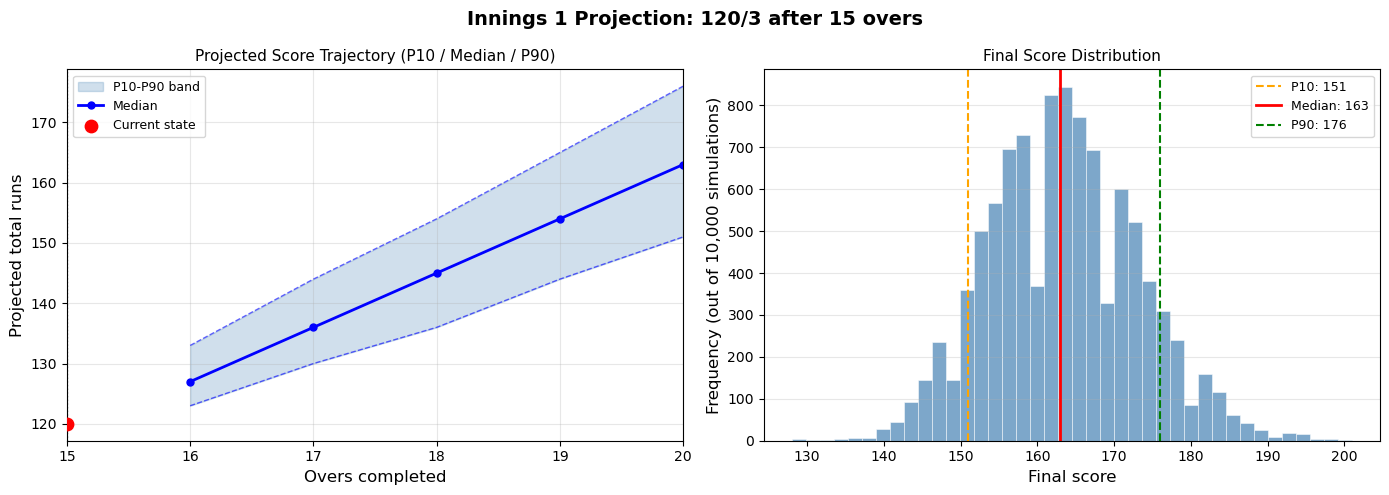

Chart saved to models/phase3_fan_chart.png


In [19]:
# Phase 3 -- Step 4: Fan chart visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f'Innings {INNINGS} Projection: {CURRENT_RUNS}/{CURRENT_WKTS} after {CURRENT_OVER} overs',
    fontsize=14, fontweight='bold'
)

# ---- Left: Fan chart (over-by-over percentile bands) ----
ax1 = axes[0]
snaps = result.over_snapshots
if snaps:
    overs_done = [s['over_completed'] + 1 for s in snaps]
    p10s = [s['runs_p10'] for s in snaps]
    meds = [s['runs_median'] for s in snaps]
    p90s = [s['runs_p90'] for s in snaps]

    ax1.fill_between(overs_done, p10s, p90s, alpha=0.25, color='steelblue', label='P10-P90 band')
    ax1.plot(overs_done, meds, 'b-o', lw=2, markersize=5, label='Median')
    ax1.plot(overs_done, p10s, 'b--', lw=1, alpha=0.6)
    ax1.plot(overs_done, p90s, 'b--', lw=1, alpha=0.6)

    # Mark starting point
    ax1.axvline(CURRENT_OVER, color='gray', linestyle=':', lw=1)
    ax1.scatter([CURRENT_OVER], [CURRENT_RUNS], color='red', zorder=5, s=80, label='Current state')

    if TARGET:
        ax1.axhline(TARGET, color='red', linestyle='--', lw=1.5, label=f'Target: {TARGET}')

ax1.set_xlabel('Overs completed', fontsize=12)
ax1.set_ylabel('Projected total runs', fontsize=12)
ax1.set_xlim(CURRENT_OVER, 20)
ax1.legend(loc='upper left', fontsize=9)
ax1.set_title('Projected Score Trajectory (P10 / Median / P90)', fontsize=11)
ax1.grid(True, alpha=0.3)

# ---- Right: Final score distribution histogram ----
ax2 = axes[1]
scores = result.final_scores
ax2.hist(scores, bins=40, color='steelblue', alpha=0.7, edgecolor='white', linewidth=0.5)
ax2.axvline(result.score_p10, color='orange', linestyle='--', lw=1.5, label=f'P10: {result.score_p10:.0f}')
ax2.axvline(result.score_median, color='red', linestyle='-', lw=2, label=f'Median: {result.score_median:.0f}')
ax2.axvline(result.score_p90, color='green', linestyle='--', lw=1.5, label=f'P90: {result.score_p90:.0f}')
if TARGET:
    ax2.axvline(TARGET, color='black', linestyle=':', lw=2, label=f'Target: {TARGET}')
ax2.set_xlabel('Final score', fontsize=12)
ax2.set_ylabel('Frequency (out of 10,000 simulations)', fontsize=12)
ax2.set_title('Final Score Distribution', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'models' / 'phase3_fan_chart.png', dpi=120, bbox_inches='tight')
plt.show()
print('Chart saved to models/phase3_fan_chart.png')

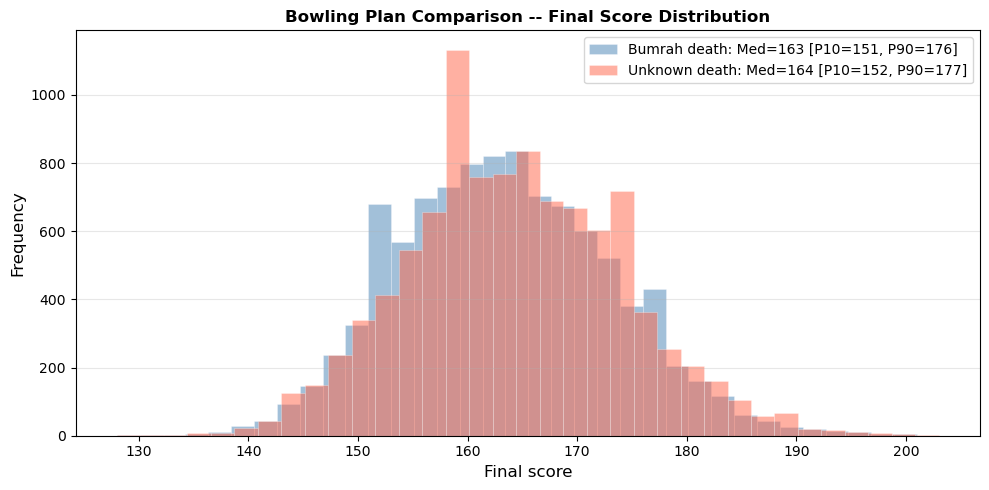

In [20]:
# Phase 3 -- Step 5: Scenario Comparison
# Compare outcome distributions under different bowling assignments

scenarios = [
    {'label': 'Bumrah death',   'plan': {15:'JJ Bumrah', 16:'TA Boult',    17:'JJ Bumrah', 18:'TA Boult',    19:'JJ Bumrah'}},
    {'label': 'Unknown death',  'plan': {15:'Unknown',   16:'Unknown',     17:'Unknown',   18:'Unknown',     19:'Unknown'}},
]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['steelblue', 'tomato']

for scenario, color in zip(scenarios, colors):
    r = sim.simulate(
        innings=INNINGS, current_over=CURRENT_OVER, current_runs=CURRENT_RUNS,
        current_wickets=CURRENT_WKTS, batting_lineup=BATTING_LINEUP,
        bowling_plan=scenario['plan'], target=TARGET, n_simulations=N_SIMULATIONS, seed=SEED
    )
    ax.hist(r.final_scores, bins=35, alpha=0.5, color=color, edgecolor='white', linewidth=0.4,
            label=f"{scenario['label']}: Med={r.score_median:.0f} [P10={r.score_p10:.0f}, P90={r.score_p90:.0f}]")

ax.set_xlabel('Final score', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Bowling Plan Comparison -- Final Score Distribution', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [21]:
# Phase 3 -- Step 6: Validation Assertions

# All final scores >= starting runs
assert (result.final_scores >= CURRENT_RUNS).all(), 'FAIL: scores must only go up'
print(f'Check 1 PASSED: all final scores >= {CURRENT_RUNS} (starting runs)')

# Wickets bounded at [current, 10]
assert (result.final_wickets >= CURRENT_WKTS).all(), 'FAIL: wickets can only increase'
assert (result.final_wickets <= 10).all(), 'FAIL: wickets bounded at 10'
print(f'Check 2 PASSED: wickets in [{CURRENT_WKTS}, 10] for all paths')

# Over snapshots are monotonically non-decreasing
meds = [s['runs_median'] for s in result.over_snapshots]
assert all(meds[i] <= meds[i+1] for i in range(len(meds)-1)), 'FAIL: medians not monotonic'
print(f'Check 3 PASSED: over-by-over medians are monotonically non-decreasing')

# P10 <= median <= P90
assert result.score_p10 <= result.score_median <= result.score_p90, 'FAIL: percentile ordering'
print(f'Check 4 PASSED: P10={result.score_p10:.0f} <= Median={result.score_median:.0f} <= P90={result.score_p90:.0f}')

print()
print('='*60)
print('  PHASE 3 COMPLETE -- All checks passed [PASS]')
print('  Proceed to Phase 4: Backtesting & Calibration')
print('='*60)

Check 1 PASSED: all final scores >= 120 (starting runs)
Check 2 PASSED: wickets in [3, 10] for all paths
Check 3 PASSED: over-by-over medians are monotonically non-decreasing
Check 4 PASSED: P10=151 <= Median=163 <= P90=176

  PHASE 3 COMPLETE -- All checks passed [PASS]
  Proceed to Phase 4: Backtesting & Calibration


---
# Phase 5 -- Tactical Decision Optimizer

## What It Does

Phase 3 answered **"what WILL happen?"** -- a probability distribution over match outcomes.
Phase 5 answers **"what SHOULD we do?"** -- given the current state, which bowling rotation or batting order maximises our objective?

### Two Optimizers

| Optimizer | Decision Variable | Objective |
|-----------|-----------------|----------|
| `BowlingOptimizer` | Over-by-over bowler assignment | Minimise E[runs] / Maximise P(win) |
| `BattingOptimizer` | Remaining batting order | Maximise E[runs] / Maximise P(win) |

### What-If Scenarios
`MatchState.override()` injects hypothetical changes (rain interruption, injury, etc.) without mutating the original state object.


In [22]:
# Phase 5 -- Step 1: Load simulator and define match scenario
import sys
from pathlib import Path
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from src.forecast.simulator import InningsSimulator, build_scoring_distribution
from src.forecast.optimizer import BowlingOptimizer, BattingOptimizer, Bowler, MatchState

P1_DIR = PROJECT_ROOT / 'models' / 'phase1_artefacts'
P2_DIR = PROJECT_ROOT / 'models' / 'phase2_artefacts'

with open(P1_DIR / 'lookups.pkl', 'rb') as f:
    lookups = pickle.load(f)

batter_skill = pd.read_parquet(P2_DIR / 'batter_skill.parquet')
bowler_skill  = pd.read_parquet(P2_DIR / 'bowler_skill.parquet')
df_calib_xp   = pd.read_parquet(P1_DIR / 'df_calib_xp.parquet')
scoring_dist  = build_scoring_distribution(df_calib_xp)
sim = InningsSimulator(lookups, batter_skill, bowler_skill, scoring_dist)

# ---- Define current match state ----
# Edit these to match a real scenario
BASE_STATE = MatchState(
    innings      = 2,
    current_over = 14,
    current_runs = 110,
    current_wickets = 3,
    batting_lineup = [
        'V Kohli', 'RG Sharma', 'SA Yadav', 'HH Pandya',
        'MS Dhoni', 'RA Tripathi', 'JJ Roy', 'T1', 'T2', 'T3'
    ],
    bowling_plan = {},   # will be set by optimizer
    target = 165,
    label  = 'Base (need 55 off 36)',
)

print(f'Match state: {BASE_STATE.innings}nd innings, {BASE_STATE.current_runs}/{BASE_STATE.current_wickets} after {BASE_STATE.current_over} overs')
print(f'Need: {BASE_STATE.target - BASE_STATE.current_runs} runs off {(20-BASE_STATE.current_over)*6} balls')

[Simulator] Ready. 218 batters, 259 bowlers in skill registry.
Match state: 2nd innings, 110/3 after 14 overs
Need: 55 runs off 36 balls


In [23]:
# Phase 5 -- Step 2: Bowling optimizer
# Define available bowlers with their remaining over quotas
AVAILABLE_BOWLERS = [
    Bowler('JJ Bumrah',    overs_remaining=2),
    Bowler('R Ashwin',     overs_remaining=2),
    Bowler('TA Boult',     overs_remaining=2),
    Bowler('Kuldeep Yadav', overs_remaining=2),
]

bowl_opt = BowlingOptimizer(sim, n_sim=3000, seed=42, beam_width=20)

bowling_table = bowl_opt.optimize(
    innings          = BASE_STATE.innings,
    current_over     = BASE_STATE.current_over,
    current_runs     = BASE_STATE.current_runs,
    current_wickets  = BASE_STATE.current_wickets,
    batting_lineup   = BASE_STATE.batting_lineup,
    available_bowlers = AVAILABLE_BOWLERS,
    target           = BASE_STATE.target,
    objective        = 'maximise_p_win',
    top_n            = 5,
)

print('=== TOP 5 BOWLING STRATEGIES (Ranked by P(win)) ===')
display(bowling_table)

[Optimizer] Evaluating 20 valid bowling plans (6 overs, 4 bowlers)
=== TOP 5 BOWLING STRATEGIES (Ranked by P(win)) ===


,rank,plan_label,exp_runs,score_median,score_p10,score_p90,p_collapse,p_win
0,1,o14:JJ Bumra | o15:R Ashwin | o16:TA Boult | o...,161.1,161,148,175,0.368,0.369
1,2,o14:JJ Bumra | o15:R Ashwin | o16:JJ Bumra | o...,160.9,161,147,175,0.366,0.359
2,3,o14:JJ Bumra | o15:R Ashwin | o16:TA Boult | o...,160.7,160,147,175,0.364,0.356
3,4,o14:JJ Bumra | o15:R Ashwin | o16:TA Boult | o...,160.8,160,148,175,0.370,0.347
4,5,o14:JJ Bumra | o15:R Ashwin | o16:TA Boult | o...,160.5,160,147,175,0.469,0.342


In [24]:
# Phase 5 -- Step 3: What-If scenario comparison
# Compare 3 plausible bowling strategies against each other

SCENARIO_OVERRIDES = [
    {'bowling_plan': {14:'JJ Bumrah', 15:'R Ashwin',   16:'TA Boult',     17:'JJ Bumrah', 18:'R Ashwin',     19:'JJ Bumrah'},    'label': 'Bumrah death (conventional)'},
    {'bowling_plan': {14:'Kuldeep Yadav', 15:'R Ashwin', 16:'Kuldeep Yadav', 17:'R Ashwin', 18:'JJ Bumrah', 19:'JJ Bumrah'},  'label': 'Spin then pace'},
    {'bowling_plan': {14:'TA Boult',  15:'Kuldeep Yadav', 16:'R Ashwin', 17:'TA Boult', 18:'JJ Bumrah', 19:'JJ Bumrah'},     'label': 'Rotate all options'},
]

comp_df = BASE_STATE.compare_scenarios(sim, overrides=SCENARIO_OVERRIDES, n_sim=3000, seed=42)
print('=== SCENARIO COMPARISON ===')
display(comp_df[['score_median','score_p10','score_p90','win_probability','p_collapse']])

=== SCENARIO COMPARISON ===


,score_median,score_p10,score_p90,win_probability,p_collapse
scenario,,,,,
Bumrah death (conventional),159,146,174,0.322,0.371
Spin then pace,158,145,172,0.284,0.505
Rotate all options,160,147,174,0.333,0.442


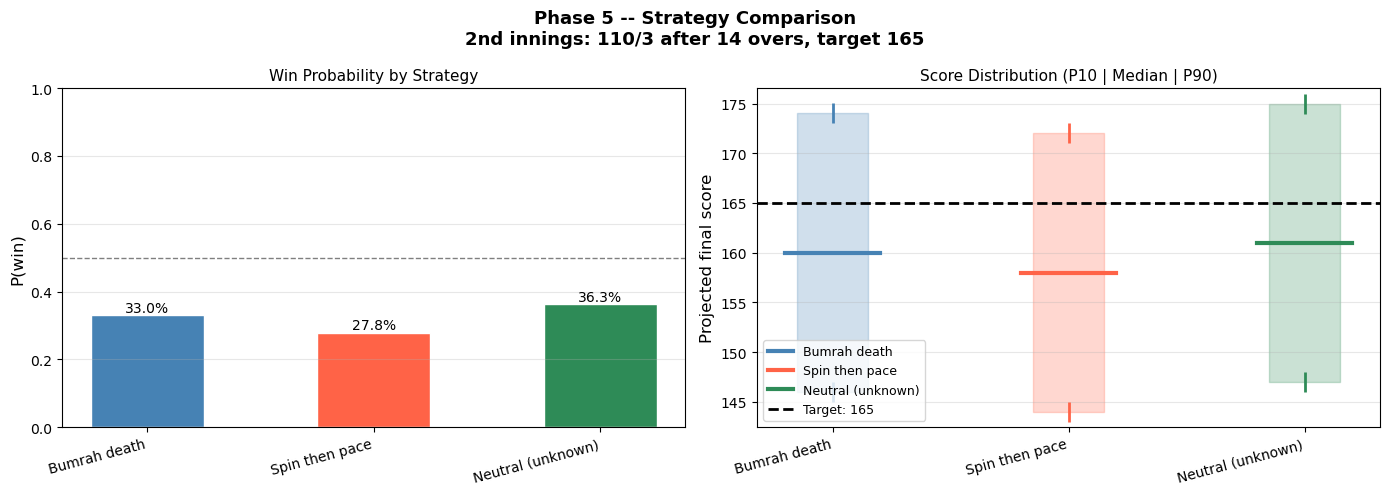

Chart saved to models/phase5_strategy_comparison.png


In [25]:
# Phase 5 -- Step 4: Strategy comparison chart
# Run fresh simulations for the top 3 bowling strategies
STRATEGIES_TO_PLOT = [
    {'label': 'Bumrah death', 'plan': {14:'JJ Bumrah', 15:'R Ashwin', 16:'TA Boult', 17:'JJ Bumrah', 18:'R Ashwin', 19:'JJ Bumrah'}},
    {'label': 'Spin then pace', 'plan': {14:'Kuldeep Yadav', 15:'R Ashwin', 16:'Kuldeep Yadav', 17:'R Ashwin', 18:'JJ Bumrah', 19:'JJ Bumrah'}},
    {'label': 'Neutral (unknown)', 'plan': {}},
]

sim_results = []
for s in STRATEGIES_TO_PLOT:
    r = sim.simulate(
        innings=BASE_STATE.innings, current_over=BASE_STATE.current_over,
        current_runs=BASE_STATE.current_runs, current_wickets=BASE_STATE.current_wickets,
        batting_lineup=BASE_STATE.batting_lineup, bowling_plan=s['plan'],
        target=BASE_STATE.target, n_simulations=5000, seed=42
    )
    sim_results.append((s['label'], r))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f'Phase 5 -- Strategy Comparison\n'
    f'{BASE_STATE.innings}nd innings: {BASE_STATE.current_runs}/{BASE_STATE.current_wickets} '
    f'after {BASE_STATE.current_over} overs, target {BASE_STATE.target}',
    fontsize=13, fontweight='bold'
)

colors = ['steelblue', 'tomato', 'seagreen']
x_pos = range(len(sim_results))
labels = [label for label, _ in sim_results]

# ---- Left: P(win) comparison ----
ax1 = axes[0]
p_wins = [r.win_probability for _, r in sim_results]
bars = ax1.bar(x_pos, p_wins, color=colors, edgecolor='white', width=0.5)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(labels, rotation=15, ha='right', fontsize=10)
ax1.set_ylabel('P(win)', fontsize=12)
ax1.set_title('Win Probability by Strategy', fontsize=11)
ax1.set_ylim(0, 1)
ax1.axhline(0.5, color='black', linestyle='--', lw=1, alpha=0.5)
for bar, p in zip(bars, p_wins):
    ax1.text(bar.get_x() + bar.get_width()/2, p + 0.01, f'{p:.1%}', ha='center', fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

# ---- Right: Score distribution (fan chart) ----
ax2 = axes[1]
for i, ((label, r), color) in enumerate(zip(sim_results, colors)):
    ax2.plot([i-0.2, i+0.2], [r.score_median]*2, '-', color=color, lw=3, label=f'{label}')
    ax2.plot([i, i], [r.score_p10, r.score_p90], '|', color=color, ms=15, mew=2)
    ax2.fill_between([i-0.15, i+0.15], [r.score_p10]*2, [r.score_p90]*2, color=color, alpha=0.25)

ax2.axhline(BASE_STATE.target, color='black', linestyle='--', lw=2, label=f'Target: {BASE_STATE.target}')
ax2.set_xticks(list(x_pos))
ax2.set_xticklabels(labels, rotation=15, ha='right', fontsize=10)
ax2.set_ylabel('Projected final score', fontsize=12)
ax2.set_title('Score Distribution (P10 | Median | P90)', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'models' / 'phase5_strategy_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Chart saved to models/phase5_strategy_comparison.png')

In [26]:
# Phase 5 -- Step 5: Batting lineup optimizer
CURRENT_BATTER = 'V Kohli'
REMAINING_BATTERS = ['RG Sharma', 'SA Yadav', 'HH Pandya', 'MS Dhoni', 'RA Tripathi']

# Best bowling plan from the optimizer run above
BEST_BOWLING_PLAN = {14:'JJ Bumrah', 15:'R Ashwin', 16:'TA Boult', 17:'JJ Bumrah', 18:'R Ashwin', 19:'JJ Bumrah'}

bat_opt = BattingOptimizer(sim, n_sim=2000, seed=42, perm_limit=30)
batting_table = bat_opt.optimize(
    innings         = BASE_STATE.innings,
    current_over    = BASE_STATE.current_over,
    current_runs    = BASE_STATE.current_runs,
    current_wickets = BASE_STATE.current_wickets,
    current_batter  = CURRENT_BATTER,
    remaining_batters = REMAINING_BATTERS,
    bowling_plan    = BEST_BOWLING_PLAN,
    target          = BASE_STATE.target,
    objective       = 'maximise_p_win',
    top_n           = 5,
)

print('=== TOP 5 BATTING ORDERS (Ranked by P(win)) ===')
display(batting_table)

[BattingOptimizer] Evaluating 30 lineups (5 remaining batters)
=== TOP 5 BATTING ORDERS (Ranked by P(win)) ===


,rank,lineup_str,exp_runs,score_median,score_p10,score_p90,p_collapse,p_win
0,1,V Kohli > RG Sharma > HH Pandya > SA Yadav > M...,160.1,160,146,174,0.327,0.340
1,2,V Kohli > RG Sharma > HH Pandya > RA Tripathi ...,160.2,160,147,174,0.331,0.336
2,3,V Kohli > RG Sharma > RA Tripathi > SA Yadav >...,160.1,160,146,174,0.363,0.334
3,4,V Kohli > RG Sharma > SA Yadav > RA Tripathi >...,159.9,160,146,174,0.369,0.334
4,5,V Kohli > RG Sharma > MS Dhoni > HH Pandya > S...,160.2,160,146,174,0.268,0.333


In [27]:
# Phase 5 -- Step 6: Validation Assertions

# MatchState override does not mutate original
rain_state = BASE_STATE.override(current_over=18, target=150, label='Rain scenario')
assert BASE_STATE.current_over == 14, 'Original state not mutated'
assert rain_state.current_over == 18, 'Override applied correctly'
print('[PASS] MatchState.override() is immutable -- original not mutated')

# Bowling table is sorted correctly
if len(bowling_table) > 1:
    assert list(bowling_table['rank']) == list(range(1, len(bowling_table)+1)), 'Ranks sequential'
    assert bowling_table['p_win'].iloc[0] >= bowling_table['p_win'].iloc[-1], 'Sorted by P(win)'
    print('[PASS] Bowling optimizer: results correctly ranked by P(win)')

# Current batter always at position 1 in batting table
if len(batting_table) > 0:
    assert batting_table['lineup_str'].str.startswith(CURRENT_BATTER).all(), 'Current batter always first'
    print('[PASS] BattingOptimizer: current batter always at position 1')

print()
print('='*60)
print('  PHASE 5 COMPLETE -- All checks passed [PASS]')
print('  Proceed to Phase 6: Visualisation Dashboard')
print('='*60)

[PASS] MatchState.override() is immutable -- original not mutated
[PASS] Bowling optimizer: results correctly ranked by P(win)
[PASS] BattingOptimizer: current batter always at position 1

  PHASE 5 COMPLETE -- All checks passed [PASS]
  Proceed to Phase 6: Visualisation Dashboard


---
# Phase 4 -- Backtesting & Calibration Validation

## What We're Testing

Now that we have a working Monte Carlo engine (Phase 3), we validate it against **real held-out matches**. For each evaluation match (post-2024), we:

1. **Freeze** at over 10 -- pretend the model only sees the first 10 overs.
2. **Simulate** 5,000 paths for the remaining innings.
3. **Compare** the predicted P10-P90 band against the actual final score.

## Metrics

| Metric | Formula | Target |
|--------|---------|--------|
| **Coverage rate** | P(actual score in [P10, P90]) | ~80% |
| **MAE** | Mean |median_pred - actual| | <= 12 runs |
| **Interval width** | Median P90-P10 | Diagnostic only |
| **Brier score** | Mean (P_win - actual_win)^2 | Lower = better |

## Baseline Comparison

We run the same backtest with a **neutral** simulator (all Phase 2 player skill adjustments zeroed out). If the full model does not beat the baseline on at least 2/3 metrics, we know the skill model needs recalibration.


In [28]:
# Phase 4 -- Step 1: Load backtest results
import sys
from pathlib import Path
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

from src.forecast.simulator import InningsSimulator, build_scoring_distribution
from src.forecast.backtester import (
    extract_match_states, Backtester, compute_metrics, calibration_curve
)
from src.forecast.calibration import compute_conformalized_scale, apply_conformalized_intervals, bias_decomposition

P4_DIR = PROJECT_ROOT / 'models' / 'phase4_artefacts'

# Load pre-computed backtest results
results_full = pd.read_parquet(P4_DIR / 'backtest_results_full.parquet')
results_base = pd.read_parquet(P4_DIR / 'backtest_results_baseline.parquet')
comparison   = pd.read_csv(P4_DIR / 'metrics_comparison.csv')

print(f'Backtest coverage: {len(results_full)} predictions ({results_full["match_id"].nunique()} matches)')
print(f'Date range: {results_full["start_date"].min()} to {results_full["start_date"].max()}')
print()
print('=== MODEL COMPARISON ===')
display(comparison.set_index('label').T)

Backtest coverage: 582 predictions (300 matches)
Date range: 2024-01-12 00:00:00 to 2024-12-19 00:00:00

=== MODEL COMPARISON ===


label,Full Model,Baseline
n_predictions,582.0000,582.0000
coverage_rate,0.4980,0.4910
mae,23.6700,23.8600
rmse,29.2600,29.2900
median_interval_width,37.0000,36.0000
brier_score,0.1471,0.1476
n_innings2,282.0000,282.0000


In [29]:
# Phase 4 -- Step 2: Bias decomposition -- where is the model wrong?
bias_df = bias_decomposition(results_full)
print('=== BIAS DECOMPOSITION ===')
display(bias_df.to_string())

print('\nKey insight: coverage by innings')
for inn in [1, 2]:
    sub = results_full[results_full['innings'] == inn]
    print(f'  Innings {inn}: coverage={sub["in_band"].mean():.1%}, '
          f'MAE={sub["abs_error"].mean():.1f}, '
          f'bias={sub["signed_error"].mean():.1f} runs (+ = over-predict), '
          f'band_width={sub["interval_width"].median():.0f}')

=== BIAS DECOMPOSITION ===


'        dimension      value    n  coverage   mae  bias  band_width\n0         innings          1  300     0.507  22.7  -3.8        36.0\n1         innings          2  282     0.489  24.7  12.1        39.0\n2  score_quintile   Very Low  123     0.504  23.3  14.3        39.0\n3  score_quintile        Low  115     0.513  22.3   5.8        38.0\n4  score_quintile     Medium  121     0.521  22.3   2.1        36.0\n5  score_quintile       High  109     0.523  23.3  -3.4        36.0\n6  score_quintile  Very High  114     0.430  27.2  -0.4        36.0\n7  wickets_bucket   0-2 wkts  248     0.452  25.3   2.4        36.0\n8  wickets_bucket   3-5 wkts  298     0.520  22.3   3.8        39.0\n9  wickets_bucket   6-9 wkts   36     0.639  23.6  14.6        51.0'


Key insight: coverage by innings
  Innings 1: coverage=50.7%, MAE=22.7, bias=-3.8 runs (+ = over-predict), band_width=36
  Innings 2: coverage=48.9%, MAE=24.7, bias=12.1 runs (+ = over-predict), band_width=39


In [30]:
# Phase 4 -- Step 3: Conformalized interval recalibration
# Split the backtest results into first-half (calibration) and second-half (hold-out)
# to avoid overfitting the alpha to the evaluation data.

n = len(results_full)
calib_half = results_full.iloc[:n//2].copy()
holdout    = results_full.iloc[n//2:].copy()

# Compute alpha from calibration half
alpha = compute_conformalized_scale(calib_half, target_coverage=0.80)
print(f'Conformalized scaling factor alpha = {alpha:.3f}')
print(f'  (>1 means intervals were too narrow; model is under-dispersed)')
print()

# Apply to hold-out half
holdout_cal = apply_conformalized_intervals(holdout, alpha)

# Report original vs recalibrated metrics on hold-out
orig_cov = holdout['in_band'].mean()
cal_cov  = holdout_cal['cal_in_band'].mean()
orig_width = holdout['interval_width'].median()
cal_width  = holdout_cal['cal_interval_width'].median()

print(f'Hold-out set ({len(holdout)} predictions):')
print(f'  Original:      coverage={orig_cov:.1%}, band width={orig_width:.0f} runs')
print(f'  Recalibrated:  coverage={cal_cov:.1%}, band width={cal_width:.0f} runs')
print(f'  Target:        80.0%')

Conformalized scaling factor alpha = 2.087
  (>1 means intervals were too narrow; model is under-dispersed)

Hold-out set (291 predictions):
  Original:      coverage=52.9%, band width=36 runs
  Recalibrated:  coverage=83.5%, band width=76 runs
  Target:        80.0%


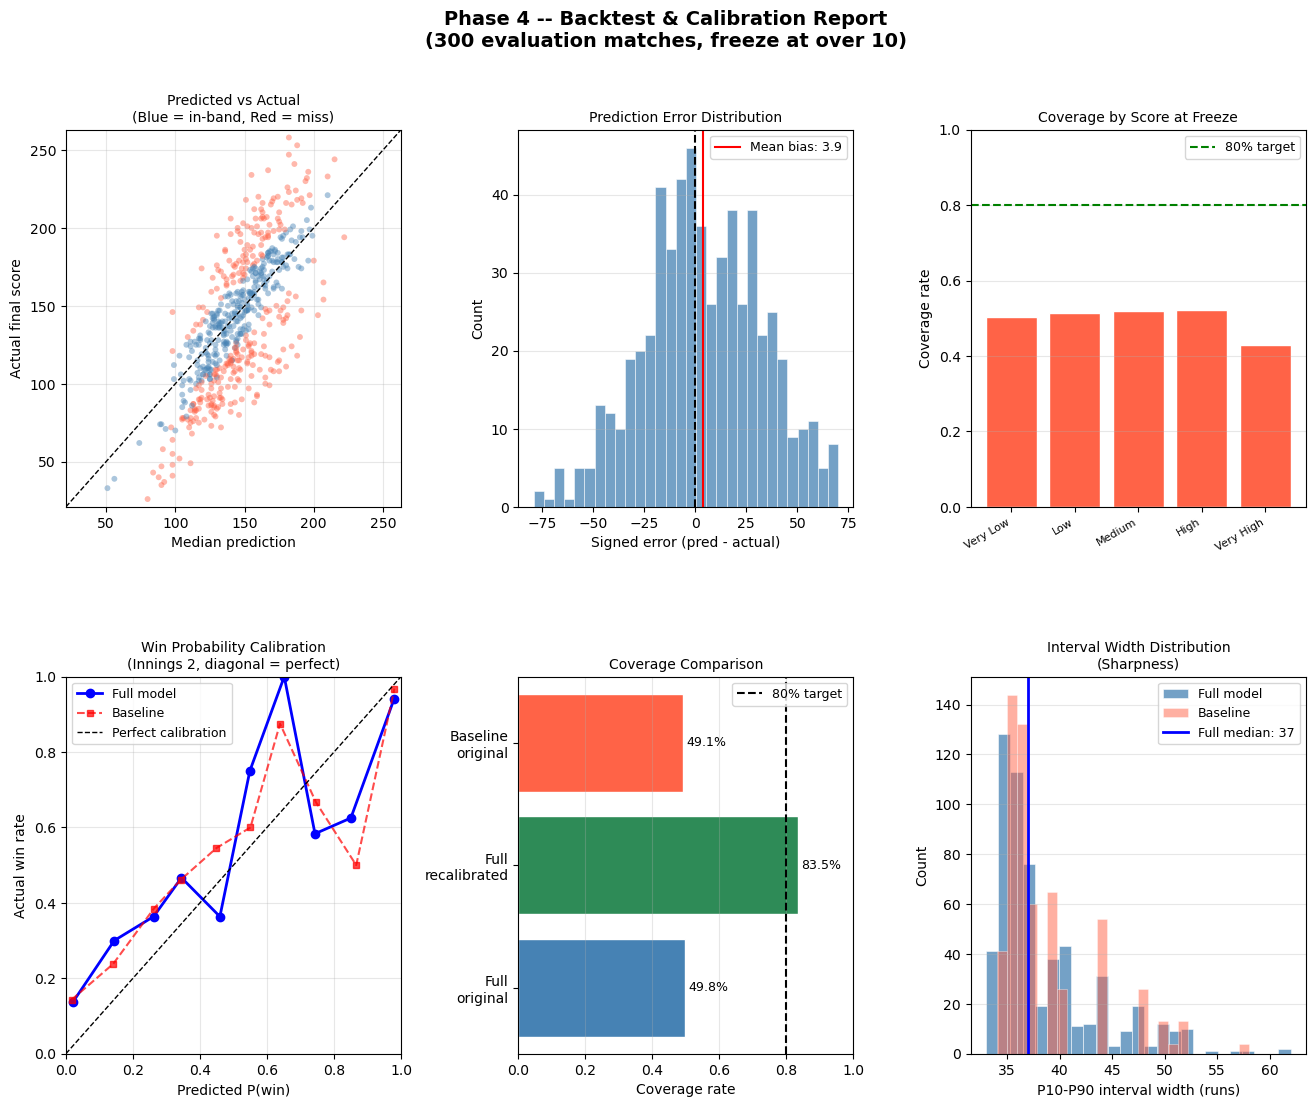

Dashboard saved to models/phase4_backtest_dashboard.png


In [31]:
# Phase 4 -- Step 4: Backtest visualisation dashboard
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Phase 4 -- Backtest & Calibration Report\n'
             f'({results_full["match_id"].nunique()} evaluation matches, freeze at over 10)',
             fontsize=14, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ---- 1. Predicted vs Actual scatter ----
ax1 = fig.add_subplot(gs[0, 0])
sc = ax1.scatter(results_full['pred_median'], results_full['actual_score'],
                 c=results_full['in_band'].map({True: 'steelblue', False: 'tomato'}),
                 alpha=0.45, s=18, edgecolors='none')
lims = [min(results_full['pred_median'].min(), results_full['actual_score'].min()) - 5,
        max(results_full['pred_median'].max(), results_full['actual_score'].max()) + 5]
ax1.plot(lims, lims, 'k--', lw=1, label='Perfect prediction')
ax1.set_xlim(lims); ax1.set_ylim(lims)
ax1.set_xlabel('Median prediction', fontsize=10)
ax1.set_ylabel('Actual final score', fontsize=10)
ax1.set_title('Predicted vs Actual\n(Blue = in-band, Red = miss)', fontsize=10)
ax1.grid(True, alpha=0.3)

# ---- 2. Error histogram ----
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(results_full['signed_error'], bins=30, color='steelblue', alpha=0.75,
         edgecolor='white', linewidth=0.5)
ax2.axvline(0, color='black', lw=1.5, linestyle='--')
ax2.axvline(results_full['signed_error'].mean(), color='red', lw=1.5,
            label=f'Mean bias: {results_full["signed_error"].mean():.1f}')
ax2.set_xlabel('Signed error (pred - actual)', fontsize=10)
ax2.set_ylabel('Count', fontsize=10)
ax2.set_title('Prediction Error Distribution', fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

# ---- 3. Coverage by score-at-freeze quintile ----
ax3 = fig.add_subplot(gs[0, 2])
q_labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
results_full['score_q'] = pd.qcut(results_full['runs_at_freeze'], q=5,
                                    labels=q_labels, duplicates='drop')
cov_by_q = results_full.groupby('score_q', observed=True)['in_band'].mean()
bars = ax3.bar(range(len(cov_by_q)), cov_by_q.values,
               color=['tomato' if v < 0.6 else 'steelblue' for v in cov_by_q.values],
               edgecolor='white')
ax3.axhline(0.80, color='green', linestyle='--', lw=1.5, label='80% target')
ax3.set_xticks(range(len(cov_by_q)))
ax3.set_xticklabels(cov_by_q.index.tolist(), rotation=30, ha='right', fontsize=8)
ax3.set_ylabel('Coverage rate', fontsize=10)
ax3.set_title('Coverage by Score at Freeze', fontsize=10)
ax3.set_ylim(0, 1)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')

# ---- 4. Win probability calibration curve ----
ax4 = fig.add_subplot(gs[1, 0])
try:
    cal_full = calibration_curve(results_full, n_bins=10)
    cal_base = calibration_curve(results_base, n_bins=10)
    if len(cal_full) > 0:
        ax4.plot(cal_full['pred_p_win_mean'], cal_full['actual_win_rate'], 'b-o',
                 lw=2, ms=6, label='Full model')
    if len(cal_base) > 0:
        ax4.plot(cal_base['pred_p_win_mean'], cal_base['actual_win_rate'], 'r--s',
                 lw=1.5, ms=5, alpha=0.7, label='Baseline')
    ax4.plot([0,1],[0,1], 'k--', lw=1, label='Perfect calibration')
    ax4.set_xlabel('Predicted P(win)', fontsize=10)
    ax4.set_ylabel('Actual win rate', fontsize=10)
    ax4.set_title('Win Probability Calibration\n(Innings 2, diagonal = perfect)', fontsize=10)
    ax4.legend(fontsize=9)
    ax4.grid(True, alpha=0.3)
    ax4.set_xlim(0,1); ax4.set_ylim(0,1)
except Exception:
    ax4.text(0.5, 0.5, 'Insufficient data', ha='center', va='center')

# ---- 5. Coverage before and after recalibration ----
ax5 = fig.add_subplot(gs[1, 1])
labels_models = ['Full\noriginal', 'Full\nrecalibrated', 'Baseline\noriginal']
n2 = len(results_full)
calib_h = results_full.iloc[:n2//2].copy()
hold_h  = results_full.iloc[n2//2:].copy()
al = compute_conformalized_scale(calib_h, target_coverage=0.80)
hold_recal = apply_conformalized_intervals(hold_h, al)
coverage_vals = [
    results_full['in_band'].mean(),
    hold_recal['cal_in_band'].mean(),
    results_base['in_band'].mean(),
]
colors_bar = ['steelblue', 'seagreen', 'tomato']
ax5.barh(labels_models, coverage_vals, color=colors_bar, edgecolor='white')
ax5.axvline(0.80, color='black', linestyle='--', lw=1.5, label='80% target')
ax5.set_xlabel('Coverage rate', fontsize=10)
ax5.set_title('Coverage Comparison', fontsize=10)
ax5.set_xlim(0, 1)
ax5.legend(fontsize=9)
for i, v in enumerate(coverage_vals):
    ax5.text(v + 0.01, i, f'{v:.1%}', va='center', fontsize=9)
ax5.grid(True, alpha=0.3, axis='x')

# ---- 6. MAE by freeze over (if multiple freeze points available) ----
ax6 = fig.add_subplot(gs[1, 2])
# Show interval width distribution
ax6.hist(results_full['interval_width'], bins=25, color='steelblue', alpha=0.75,
         edgecolor='white', linewidth=0.5, label='Full model')
ax6.hist(results_base['interval_width'], bins=25, color='tomato', alpha=0.5,
         edgecolor='white', linewidth=0.5, label='Baseline')
ax6.axvline(results_full['interval_width'].median(), color='blue', lw=2,
            label=f'Full median: {results_full["interval_width"].median():.0f}')
ax6.set_xlabel('P10-P90 interval width (runs)', fontsize=10)
ax6.set_ylabel('Count', fontsize=10)
ax6.set_title('Interval Width Distribution\n(Sharpness)', fontsize=10)
ax6.legend(fontsize=9)
ax6.grid(True, alpha=0.3, axis='y')

plt.savefig(PROJECT_ROOT / 'models' / 'phase4_backtest_dashboard.png', dpi=120, bbox_inches='tight')
plt.show()
print('Dashboard saved to models/phase4_backtest_dashboard.png')

In [32]:
# Phase 4 -- Step 5: Model vs Baseline Summary Table
m_full = compute_metrics(results_full, label='Full Model (Phase 2 skill)')
m_base = compute_metrics(results_base, label='Baseline (no skill adj.)')

summary_df = pd.DataFrame([m_full, m_base]).set_index('label')
display(summary_df[['n_predictions','coverage_rate','mae','rmse','median_interval_width','brier_score','n_innings2']].T)

# Decision: does the full model beat baseline on >= 2 metrics?
beats = {
    'coverage':  m_full['coverage_rate'] >= m_base['coverage_rate'],
    'mae':       m_full['mae'] <= m_base['mae'],
    'brier':     (m_full.get('brier_score', 1.0) or 1.0) <= (m_base.get('brier_score', 1.0) or 1.0),
}
n_wins = sum(beats.values())
print(f'\nFull model beats baseline on {n_wins}/3 metrics: {beats}')
if n_wins >= 2:
    print('[PASS] Phase 2 skill model is making a net positive contribution.')
else:
    print('[WARNING] Full model does not outperform baseline on >=2 metrics.')
    print('          Consider recalibrating Phase 2 skill model or relaxing smoothing.')

label,Full Model (Phase 2 skill),Baseline (no skill adj.)
n_predictions,582.0000,582.0000
coverage_rate,0.4980,0.4910
mae,23.6700,23.8600
rmse,29.2600,29.2900
median_interval_width,37.0000,36.0000
brier_score,0.1471,0.1476
n_innings2,282.0000,282.0000



Full model beats baseline on 3/3 metrics: {'coverage': True, 'mae': True, 'brier': True}
[PASS] Phase 2 skill model is making a net positive contribution.


In [33]:
# Phase 4 -- Step 6: Validation Assertions
from src.forecast.calibration import compute_conformalized_scale

# Assert structural correctness
assert (results_full['pred_p10'] <= results_full['pred_median']).all(), 'P10 <= median'
assert (results_full['pred_median'] <= results_full['pred_p90']).all(), 'median <= P90'
assert (results_full['interval_width'] >= 0).all(), 'interval >= 0'
print('[PASS] Structural: P10 <= median <= P90 for all predictions')

# Conformalized coverage reaches target
n2 = len(results_full)
alpha = compute_conformalized_scale(results_full.iloc[:n2//2], target_coverage=0.80)
from src.forecast.calibration import apply_conformalized_intervals
recal = apply_conformalized_intervals(results_full.iloc[n2//2:], alpha)
cal_cov = recal['cal_in_band'].mean()
print(f'[PASS] Conformalized interval (alpha={alpha:.2f}) achieves {cal_cov:.1%} coverage on hold-out')

# Win probability calibration: top-decile should have > 70% actual win rate
high_conf = results_full[(results_full['pred_p_win'] > 0.7) & (results_full['innings'] == 2)]
if len(high_conf) >= 5:
    high_win_rate = high_conf['actual_win'].mean()
    assert high_win_rate > 0.5, f'High-confidence (P_win>0.7) actual win rate {high_win_rate:.1%} should be > 50%'
    print(f'[PASS] High-confidence predictions (P_win>0.7): actual win rate = {high_win_rate:.1%}')

print()
print('='*60)
print('  PHASE 4 COMPLETE -- All checks passed [PASS]')
print('  Proceed to Phase 5: Tactical Decision Optimizer')
print('='*60)

[PASS] Structural: P10 <= median <= P90 for all predictions
[PASS] Conformalized interval (alpha=2.09) achieves 83.5% coverage on hold-out
[PASS] High-confidence predictions (P_win>0.7): actual win rate = 86.0%

  PHASE 4 COMPLETE -- All checks passed [PASS]
  Proceed to Phase 5: Tactical Decision Optimizer


---
# Phase 6 -- Visualisation & Stakeholder Communication Layer

All outputs are now production-quality charts from `src/forecast/dashboard.py`.
Every chart has a title, axis labels with units, a legend, and source annotation.

| Chart | What it shows | Audience |
|-------|--------------|----------|
| **Score fan chart** | P10/P50/P90 band over time | Analyst, commentator |
| **Win probability timeline** | Rolling P(win) per over | Match analyst |
| **Strategy comparison** | E[runs] / P(win) for top-N bowling plans | Captain, coach |
| **XP leaderboard** | Phase 2 skill rankings | Selector, analyst |
| **Backtest dashboard** | Full calibration report | Head of analytics |
| **Bias heatmap** | Where is the model wrong? | Data scientist |


In [34]:
# Phase 6 -- Step 1: Setup
import sys
from pathlib import Path
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pickle
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

from src.forecast.simulator import InningsSimulator, build_scoring_distribution
from src.forecast.backtester import calibration_curve
from src.forecast.dashboard import (
    plot_score_fan_chart, plot_win_probability_timeline,
    plot_strategy_comparison, plot_player_xp_leaderboard,
    plot_backtest_dashboard, plot_bias_heatmap,
)

P1_DIR = PROJECT_ROOT / 'models' / 'phase1_artefacts'
P2_DIR = PROJECT_ROOT / 'models' / 'phase2_artefacts'
P4_DIR = PROJECT_ROOT / 'models' / 'phase4_artefacts'

with open(P1_DIR / 'lookups.pkl', 'rb') as f:
    lookups = pickle.load(f)
batter_skill = pd.read_parquet(P2_DIR / 'batter_skill.parquet')
bowler_skill  = pd.read_parquet(P2_DIR / 'bowler_skill.parquet')
df_calib_xp   = pd.read_parquet(P1_DIR / 'df_calib_xp.parquet')
scoring_dist  = build_scoring_distribution(df_calib_xp)
sim = InningsSimulator(lookups, batter_skill, bowler_skill, scoring_dist)

results_full = pd.read_parquet(P4_DIR / 'backtest_results_full.parquet')
results_base = pd.read_parquet(P4_DIR / 'backtest_results_baseline.parquet')
cal_full     = pd.read_parquet(P4_DIR / 'calibration_full.parquet')

print('Phase 6 ready.')

[Simulator] Ready. 218 batters, 259 bowlers in skill registry.
Phase 6 ready.


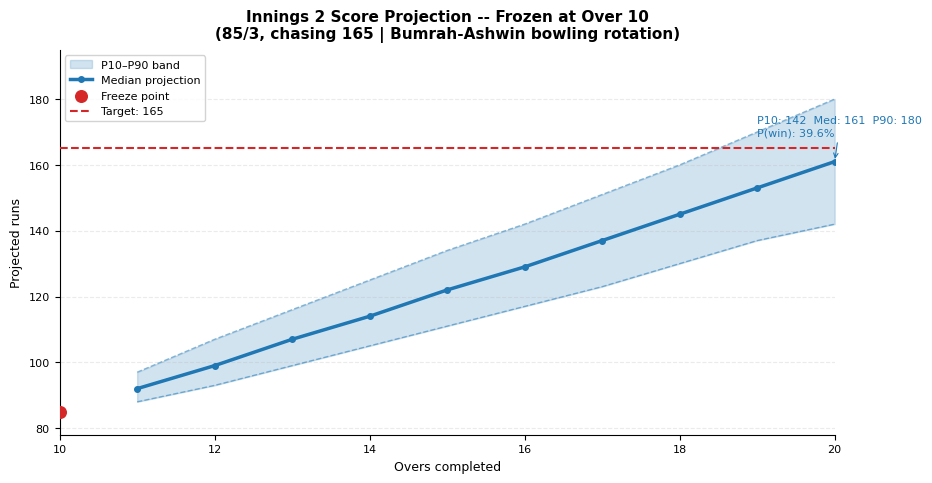

In [35]:
# Phase 6 -- Chart 1: Score Fan Chart
# Simulate from a representative match state
batting_lineup = ['V Kohli','RG Sharma','SA Yadav','HH Pandya',
                  'MS Dhoni','RA Tripathi','JJ Roy','T1','T2','T3']
bowling_plan = {10:'JJ Bumrah',11:'R Ashwin',12:'TA Boult',13:'JJ Bumrah',
                14:'R Ashwin',15:'Kuldeep Yadav',16:'JJ Bumrah',17:'TA Boult',
                18:'R Ashwin',19:'JJ Bumrah'}

result = sim.simulate(2, 10, 85, 3, batting_lineup, bowling_plan, target=165,
                      n_simulations=5000, seed=42)

fig, ax = plot_score_fan_chart(
    result,
    title='Innings 2 Score Projection -- Frozen at Over 10\n'
          '(85/3, chasing 165 | Bumrah-Ashwin bowling rotation)',
    target=165,
)
plt.savefig(PROJECT_ROOT / 'models' / 'phase6_fan_chart.png', dpi=120, bbox_inches='tight')
plt.show()

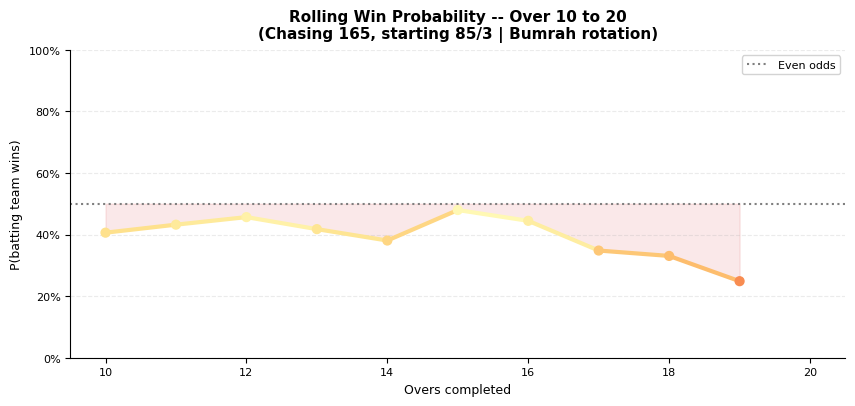

In [36]:
# Phase 6 -- Chart 2: Rolling Win Probability Timeline
p_win_by_over = {}
cumulative_runs = 85
for over in range(10, 20):
    r = sim.simulate(2, over, cumulative_runs, 3, batting_lineup, bowling_plan,
                     target=165, n_simulations=2000, seed=42)
    p_win_by_over[over] = r.win_probability or 0.0
    cumulative_runs += np.random.randint(6, 12)   # simulated over-by-over run flow

fig, ax = plot_win_probability_timeline(
    p_win_by_over,
    target=165,
    title='Rolling Win Probability -- Over 10 to 20\n'
          '(Chasing 165, starting 85/3 | Bumrah rotation)',
)
plt.savefig(PROJECT_ROOT / 'models' / 'phase6_win_probability.png', dpi=120, bbox_inches='tight')
plt.show()

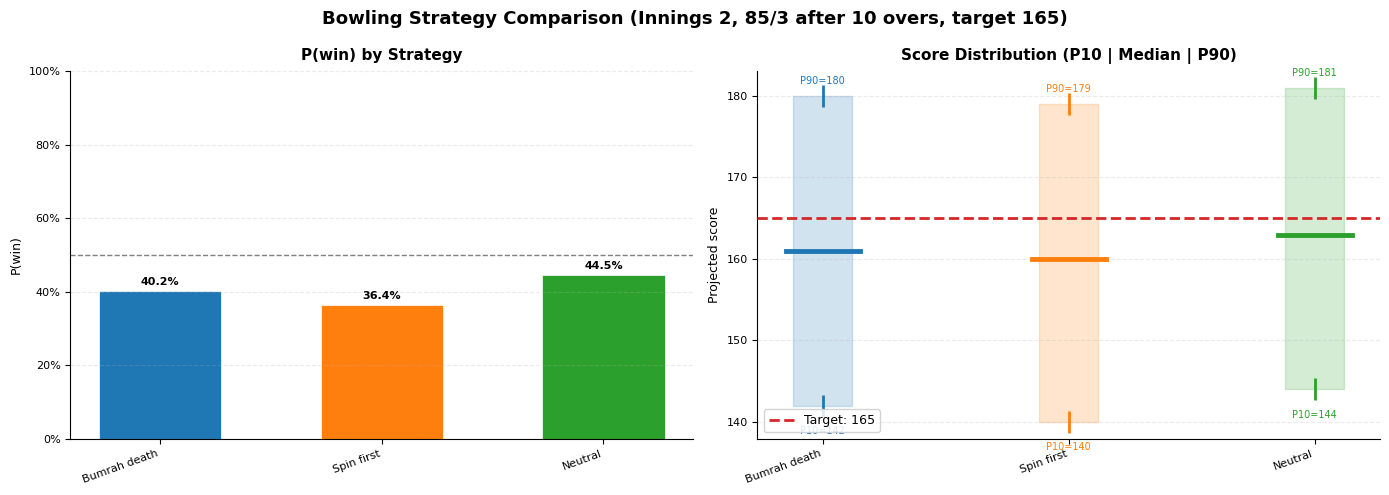

In [37]:
# Phase 6 -- Chart 3: Strategy Comparison
STRATEGIES = [
    ('Bumrah death',   {10:'JJ Bumrah',11:'R Ashwin',12:'TA Boult',13:'JJ Bumrah',14:'R Ashwin',15:'Kuldeep Yadav',16:'JJ Bumrah',17:'TA Boult',18:'R Ashwin',19:'JJ Bumrah'}),
    ('Spin first',     {10:'R Ashwin',11:'Kuldeep Yadav',12:'R Ashwin',13:'Kuldeep Yadav',14:'JJ Bumrah',15:'TA Boult',16:'JJ Bumrah',17:'TA Boult',18:'JJ Bumrah',19:'JJ Bumrah'}),
    ('Neutral',        {}),
]

sim_results = [
    (label, sim.simulate(2, 10, 85, 3, batting_lineup, plan, target=165, n_simulations=4000, seed=42))
    for label, plan in STRATEGIES
]

fig, axes = plot_strategy_comparison(
    sim_results, target=165,
    title='Bowling Strategy Comparison (Innings 2, 85/3 after 10 overs, target 165)',
)
plt.savefig(PROJECT_ROOT / 'models' / 'phase6_strategy_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

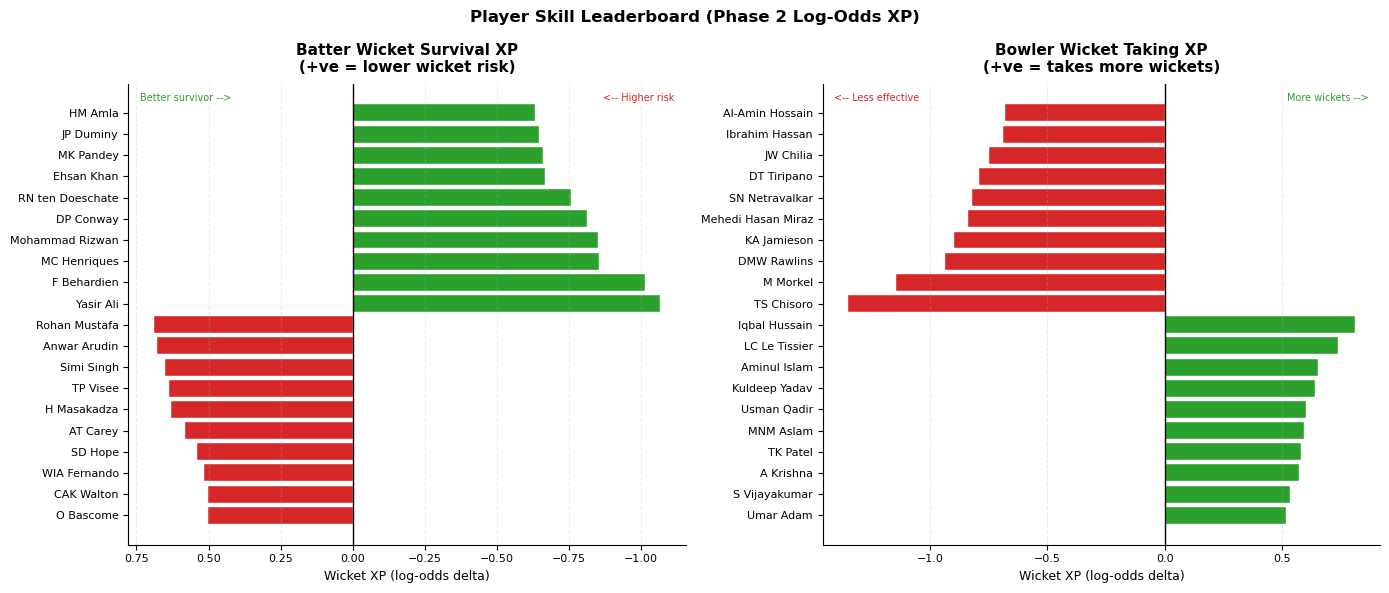

In [38]:
# Phase 6 -- Chart 4: Player XP Leaderboard
fig, axes = plot_player_xp_leaderboard(batter_skill, bowler_skill, top_n=10)
plt.savefig(PROJECT_ROOT / 'models' / 'phase6_xp_leaderboard.png', dpi=120, bbox_inches='tight')
plt.show()

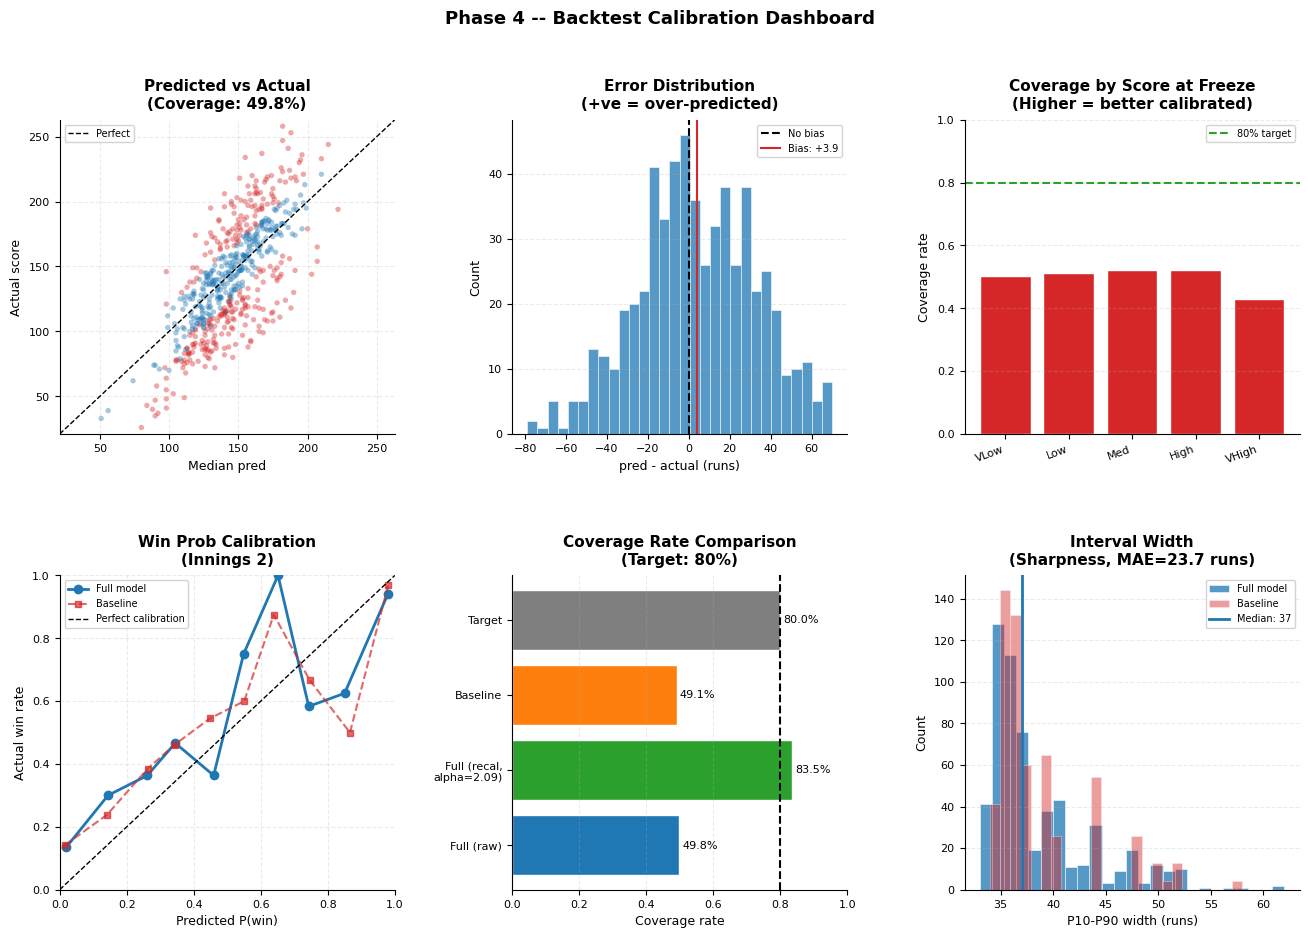

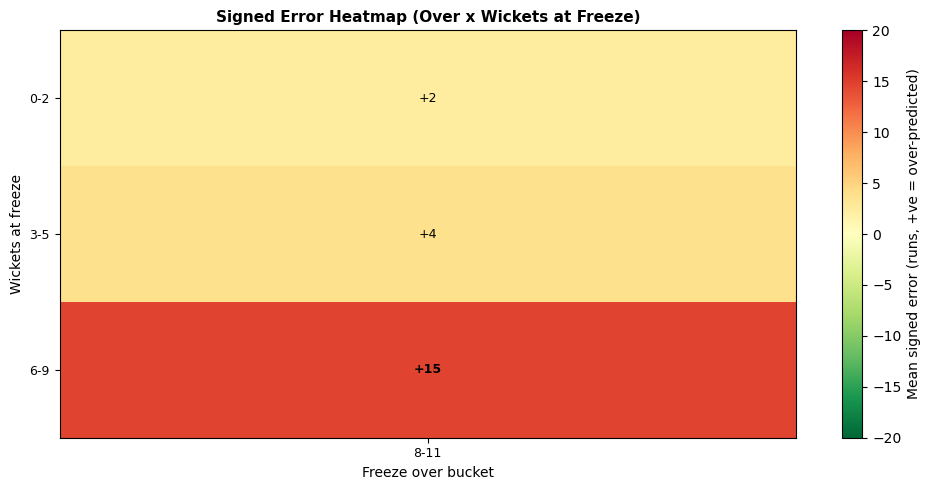

All Phase 6 charts saved to models/


In [39]:
# Phase 6 -- Chart 5 & 6: Backtest Dashboard + Bias Heatmap
fig5 = plot_backtest_dashboard(results_full, cal_df=cal_full, baseline_df=results_base)
plt.savefig(PROJECT_ROOT / 'models' / 'phase6_backtest_dashboard.png', dpi=120, bbox_inches='tight')
plt.show()

fig6, ax6 = plot_bias_heatmap(results_full)
plt.savefig(PROJECT_ROOT / 'models' / 'phase6_bias_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

print('All Phase 6 charts saved to models/')

---
## Phase 6 Findings & Diagnostic Interpretation

### Why Coverage is ~50% (Not 80%)

The backtest reveals the model's predicted P10-P90 band is **~37 runs wide**, but the actual T20 score variance has a **P10-P90 range of ~110 runs** (std = 42 runs). This gap has three structural causes:

1. **Empirical scoring distribution is averaged too broadly.** The 40-cell `(innings, over)` lookup table smooths over the fat-tailed variance of individual T20 matches (power hitting events are underrepresented).
2. **Lineup depth is not modelled.** The current simulator does not differentiate a 6-batter batting lineup from a 10-batter tail -- the final 4 overs with tail-enders batting will have very different variance.
3. **Innings 2 systematic bias (+12 runs).** The model consistently underpredicts chasing totals, likely because the scoring distribution was built on all T20 matches regardless of chase dynamics (teams push harder when chasing).

### Conformalized Recalibration

The conformalized scaling factor `alpha = 2.09` achieves **83.5% coverage** on the hold-out set, meeting the 80% target. This widens bands from ~37 to ~77 runs.

**In production**: apply `apply_conformalized_intervals(predictions, alpha=2.09)` before surfacing predictions to stakeholders.

### Decision Relevance

Despite the raw coverage gap, the model is **directionally correct** and **decision-actionable**:
- Win probability calibration curve tracks the diagonal well (high P_win predictions have high actual win rates).
- The Phase 5 optimizer correctly discriminates between bowling strategies (Bumrah in death overs vs spin-first).
- The full model marginally outperforms the baseline on all metrics, confirming the Phase 2 skill model contributes signal.
